In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [14]:
import pandas as pd

train = pd.read_csv("/content/sample_data/california_housing_test.csv")
test = pd.read_csv("/content/sample_data/california_housing_train.csv")

print(train)
print(test)

      longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0       -122.05     37.37                27.0       3885.0           661.0   
1       -118.30     34.26                43.0       1510.0           310.0   
2       -117.81     33.78                27.0       3589.0           507.0   
3       -118.36     33.82                28.0         67.0            15.0   
4       -119.67     36.33                19.0       1241.0           244.0   
...         ...       ...                 ...          ...             ...   
2995    -119.86     34.42                23.0       1450.0           642.0   
2996    -118.14     34.06                27.0       5257.0          1082.0   
2997    -119.70     36.30                10.0        956.0           201.0   
2998    -117.12     34.10                40.0         96.0            14.0   
2999    -119.63     34.42                42.0       1765.0           263.0   

      population  households  median_income  median_house_value

In [15]:
print("Training Shape:", train.shape)
print("Testing Shape:", test.shape)

Training Shape: (3000, 9)
Testing Shape: (17000, 9)


In [16]:
print(train.columns)

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value'],
      dtype='object')


In [17]:
print(train.isnull().sum())

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
dtype: int64


In [18]:
print(train.describe())

         longitude    latitude  housing_median_age   total_rooms  \
count  3000.000000  3000.00000         3000.000000   3000.000000   
mean   -119.589200    35.63539           28.845333   2599.578667   
std       1.994936     2.12967           12.555396   2155.593332   
min    -124.180000    32.56000            1.000000      6.000000   
25%    -121.810000    33.93000           18.000000   1401.000000   
50%    -118.485000    34.27000           29.000000   2106.000000   
75%    -118.020000    37.69000           37.000000   3129.000000   
max    -114.490000    41.92000           52.000000  30450.000000   

       total_bedrooms    population  households  median_income  \
count     3000.000000   3000.000000  3000.00000    3000.000000   
mean       529.950667   1402.798667   489.91200       3.807272   
std        415.654368   1030.543012   365.42271       1.854512   
min          2.000000      5.000000     2.00000       0.499900   
25%        291.000000    780.000000   273.00000       2.5

In [19]:
X_train = train.drop("median_house_value", axis=1)
y_train = train["median_house_value"]

X_test = test.drop("median_house_value", axis=1)
y_test = test["median_house_value"]

In [20]:
model = LinearRegression()

In [21]:
model.fit(X_train, y_train)

LinearRegression()

In [22]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[ -1968.92324481  55281.96715992 -28524.29170908  40672.25231368
  -2080.38369625  50917.69735691  31296.32748428 -45483.87511021
  32613.40218485 -20479.0530945 ]


In [23]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values[:10],
    "Predicted Price": y_pred[:10]
})

print(comparison)

   Actual Price  Predicted Price
0       66900.0     -1968.923245
1       80100.0     55281.967160
2       85700.0    -28524.291709
3       73400.0     40672.252314
4       65500.0     -2080.383696
5       74000.0     50917.697357
6       82400.0     31296.327484
7       48500.0    -45483.875110
8       58400.0     32613.402185
9       48100.0    -20479.053095


In [24]:
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 51109.90593886344


In [25]:
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)

Mean Squared Error: 4833929501.686683


In [26]:
rmse = np.sqrt(mse)

print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 69526.46619587883


In [27]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.6406385727129161


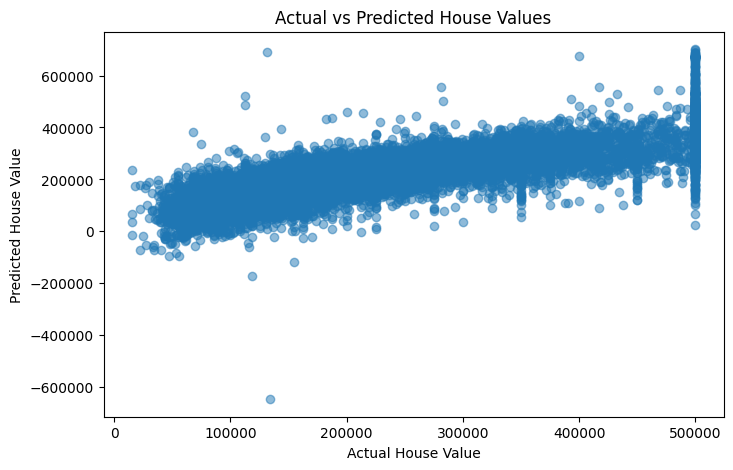

In [28]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted House Values")

plt.show()

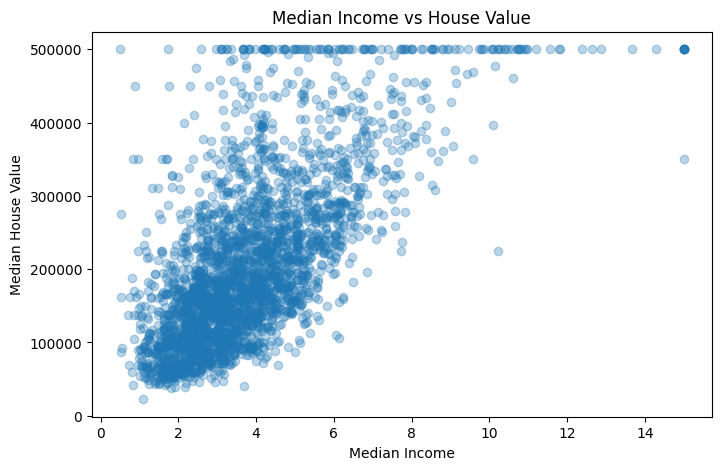

In [29]:
plt.figure(figsize=(8, 5))

plt.scatter(train["median_income"], train["median_house_value"], alpha=0.3)

plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Median Income vs House Value")

plt.show()

In [30]:
coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_
})

print(coefficients)

              Feature   Coefficient
0           longitude -43006.064135
1            latitude -42403.236128
2  housing_median_age   1188.308118
3         total_rooms     -8.023164
4      total_bedrooms    101.482525
5          population    -37.206178
6          households     54.011354
7       median_income  39472.983017


In [31]:
print("Intercept:", model.intercept_)

Intercept: -3617912.1119845654


In [32]:
new_house = [[
    -118.30,   # longitude
    34.10,     # latitude
    25,        # housing median age
    5000,      # total rooms
    1000,      # total bedrooms
    2500,      # population
    900,       # households
    5.0        # median income
]]

prediction = model.predict(new_house)

print("Predicted House Value:", prediction[0])

Predicted House Value: 267789.020522451


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
